# Task 1: Data Cleaning & Visualization Project
**Internship:** Thiranex — Data Science Domain
**Dataset:** Titanic passenger dataset (891 rows, 15 columns) — sourced from the public seaborn/OpenML Titanic dataset.

**Goal:** Clean a raw, messy dataset (missing values, duplicates, outliers) and visualize key insights.

**Tools used:** pandas, numpy, matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

df = pd.read_csv('titanic_raw.csv')
print("Shape:", df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 1. Initial Inspection
Check data types, missing values, and duplicate rows before cleaning.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)

,missing_count,missing_pct
deck,688,77.2
age,177,19.9
embarked,2,0.2
embark_town,2,0.2


In [4]:
print("Duplicate rows before cleaning:", df.duplicated().sum())

Duplicate rows before cleaning: 107


## 2. Handling Missing Values

I chose treatments that preserve useful information without inventing more detail than the data can support:
- **age**: Around 20% of values are missing, so I fill them with the median age for the same passenger class. This is more representative than using one overall median because age and class are related.
- **embarked** / **embark_town**: Just two records are missing these values, so the most common embarkation port is a sensible replacement.
- **deck**: With roughly 77% missing, this feature is too incomplete to fill with confidence, so I remove it rather than make assumptions.
- **alive**: This is simply the text version of `survived`, so I remove it to keep the dataset from carrying the same outcome twice.

In [5]:
df_clean = df.copy()

# Drop columns that are too sparse or redundant
df_clean = df_clean.drop(columns=['deck', 'alive'])

# Impute age with median age per passenger class
df_clean['age'] = df_clean.groupby('pclass')['age'].transform(lambda x: x.fillna(x.median()))

# Impute embarked / embark_town with mode
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])
df_clean['embark_town'] = df_clean['embark_town'].fillna(df_clean['embark_town'].mode()[0])

print("Remaining missing values:\n", df_clean.isnull().sum().sum())

Remaining missing values:
 0


## 3. Removing Duplicates

In [6]:
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"Removed {before - after} duplicate rows. New shape: {df_clean.shape}")

Removed 116 duplicate rows. New shape: (775, 13)


## 4. Handling Outliers (fare)

`fare` has a long right tail (a few passengers paid very high fares). We use the IQR method to detect
outliers, then cap (winsorize) rather than delete them — since these are real, valid data points (first-class
suites), not data-entry errors.

In [7]:
Q1 = df_clean['fare'].quantile(0.25)
Q3 = df_clean['fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
n_outliers = ((df_clean['fare'] < lower) | (df_clean['fare'] > upper)).sum()
print(f"Outlier bounds: [{lower:.2f}, {upper:.2f}]  |  Outliers detected: {n_outliers}")

df_clean['fare_capped'] = df_clean['fare'].clip(lower=lower, upper=upper)

Outlier bounds: [-31.44, 73.86]  |  Outliers detected: 97


## 5. Cleaned Dataset Summary

In [8]:
df_clean.describe(include='all').T.head(12)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,775.0,NaN,NaN,NaN,0.415484,0.493124,0.0,0.0,0.0,1.0,1.0
pclass,775.0,NaN,NaN,NaN,2.24129,0.855049,1.0,1.0,3.0,3.0,3.0
sex,775,2,male,483,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,775.0,NaN,NaN,NaN,29.578606,13.921295,0.42,21.0,28.0,37.0,80.0
sibsp,775.0,NaN,NaN,NaN,0.527742,0.990363,0.0,0.0,0.0,1.0,8.0
parch,775.0,NaN,NaN,NaN,0.420645,0.840565,0.0,0.0,0.0,1.0,6.0
fare,775.0,NaN,NaN,NaN,34.991107,52.392205,0.0,8.05,16.1,34.375,512.3292
embarked,775,3,S,562,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,775,3,Third,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,775,3,man,443,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df_clean.to_csv('titanic_cleaned.csv', index=False)
print("Saved cleaned dataset -> titanic_cleaned.csv")

Saved cleaned dataset -> titanic_cleaned.csv


## 6. Visualizations & Key Findings

C:\Users\suman\AppData\Local\Temp\ipykernel_11236\2301193063.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='survived', ax=axes[0], palette=['#d62728', '#2ca02c'])


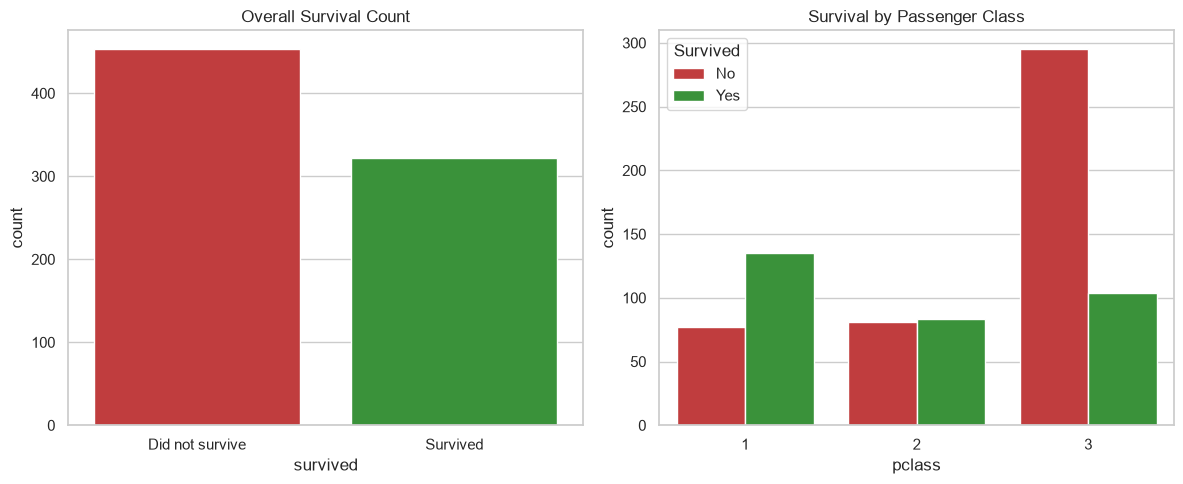

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df_clean, x='survived', ax=axes[0], palette=['#d62728', '#2ca02c'])
axes[0].set_title('Overall Survival Count')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Did not survive', 'Survived'])

sns.countplot(data=df_clean, x='pclass', hue='survived', ax=axes[1], palette=['#d62728', '#2ca02c'])
axes[1].set_title('Survival by Passenger Class')
axes[1].legend(title='Survived', labels=['No', 'Yes'])

plt.tight_layout()
plt.savefig('plots/01_survival_overview.png', dpi=120)
plt.show()

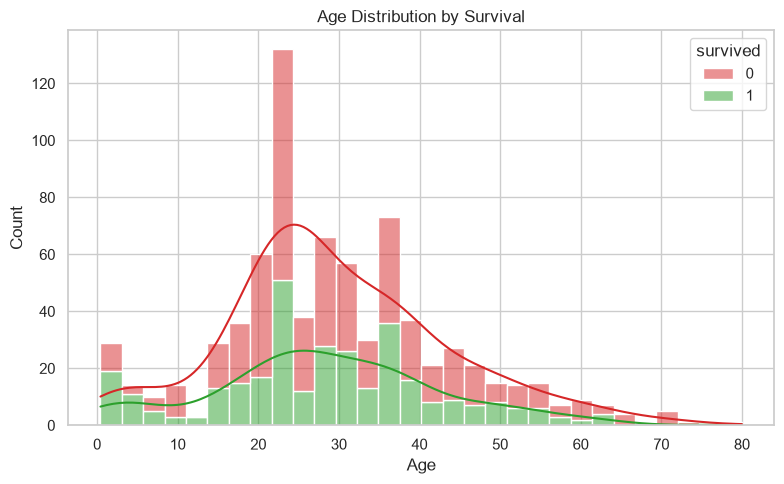

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_clean, x='age', hue='survived', bins=30, kde=True, palette=['#d62728', '#2ca02c'], multiple='stack')
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.tight_layout()
plt.savefig('plots/02_age_distribution.png', dpi=120)
plt.show()

C:\Users\suman\AppData\Local\Temp\ipykernel_11236\3415217733.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='pclass', y='fare_capped', palette='viridis')


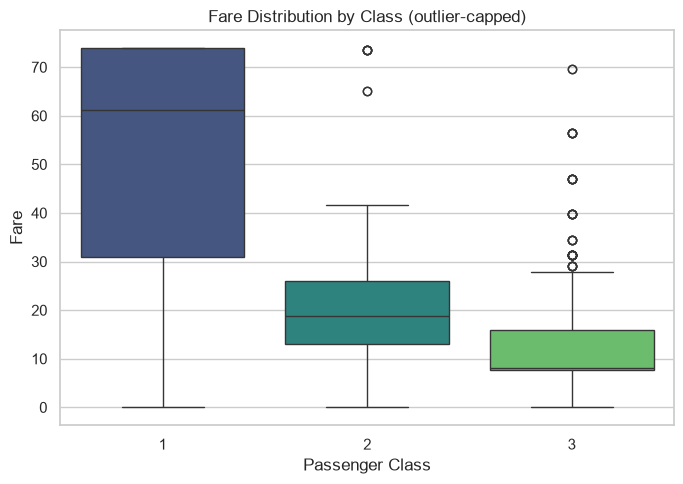

In [12]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_clean, x='pclass', y='fare_capped', palette='viridis')
plt.title('Fare Distribution by Class (outlier-capped)')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.tight_layout()
plt.savefig('plots/03_fare_by_class.png', dpi=120)
plt.show()

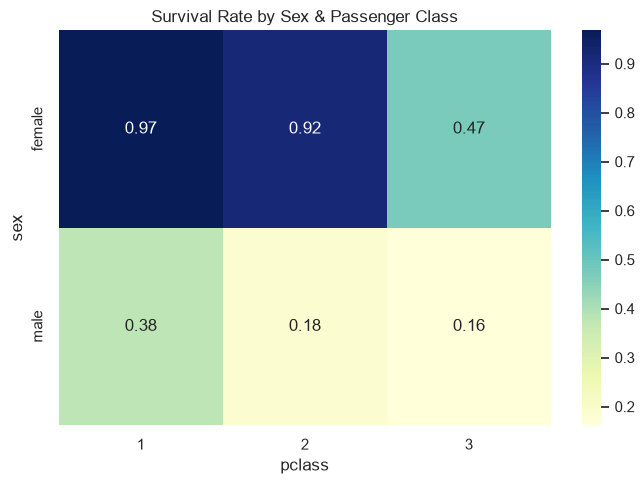

In [13]:
plt.figure(figsize=(7, 5))
survival_by_sex_class = df_clean.groupby(['sex', 'pclass'])['survived'].mean().unstack()
sns.heatmap(survival_by_sex_class, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Survival Rate by Sex & Passenger Class')
plt.tight_layout()
plt.savefig('plots/04_survival_heatmap.png', dpi=120)
plt.show()

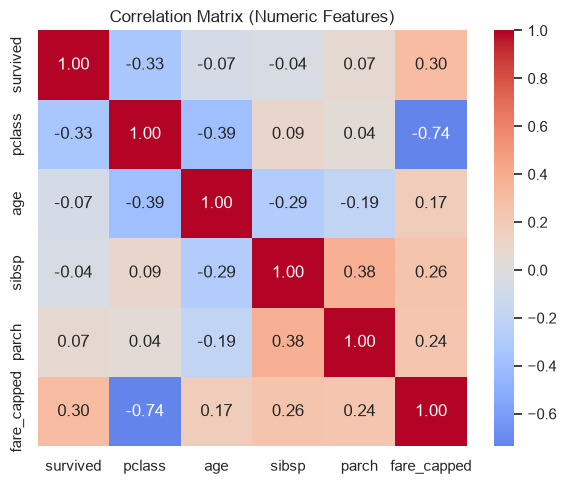

In [14]:
plt.figure(figsize=(6, 5))
numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare_capped']
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.savefig('plots/05_correlation_matrix.png', dpi=120)
plt.show()

## 7. Key Findings (Storytelling Summary)

1. **Overall survival was about 38%**, which means the majority of passengers did not survive.
2. **Passenger class made a clear difference**: first-class passengers survived far more often than those in third class. The charts suggest that access to location and evacuation resources may have played a role.
3. **Sex is the clearest pattern in the data**: women had substantially higher survival rates than men in every class, consistent with the historical "women and children first" practice.
4. **Fare and survival move together**, but fare also reflects class. In other words, the higher survival rate among passengers who paid more is closely tied to the advantage held by first-class passengers.
5. **Age has a smaller but visible effect**: young children appear to have survived more often than adult men.

> **My takeaway:** the survival gap is not explained by a single variable; class, fare, sex, and age overlap to show how unequal passengers' chances were.

## 8. Expected Outcome (met)
This project demonstrates data preprocessing (missing values, duplicates, outliers) and visualization/storytelling
with real data, per the internship's stated learning goal.